# SageServe `random_trace.csv` : Trace Analysis

This notebook documents the analysis of the synthetic `random_trace.csv` generated for the local SageServe setup.

## Goal

Understand the structure of the trace before using it for the **reactive vs. forecast-aware scaling** experiments.

### Questions investigated

- How many CSV rows are present?
- How many unique requests are present?
- How many unique arrival timestamps are present?
- What models and regions occur?
- How many rows are associated with each request/timestamp?
- What does the workload look like over time?
- Can raw CSV row counts be interpreted directly as request arrivals?


## 1. Load the trace

Expected location:

```text
traces/random_trace.csv
```

The trace was generated using SageServe's random trace generator after changing the generated model names to `A`, `B`, `C`, and `D`.

The generator was also increased to 5000 request IDs so that the simulator could run long enough to cross its result-writing checkpoint.


In [1]:
import sys

print(sys.executable)
print(sys.version)

/home/sreenath-karthick/repos/Sage-Serve/SageServe-original/.venv/bin/python
3.11.13 (main, Sep 27 2026, 20:42:01) [GCC 13.3.0]


In [2]:
from pathlib import Path
import pandas as pd

trace_path = Path("../traces/random_trace.csv")

print("Trace path:", trace_path.resolve())
print("Exists:", trace_path.exists())

df = pd.read_csv(trace_path)
df.head()

Trace path: /home/sreenath-karthick/repos/Sage-Serve/SageServe-original/traces/random_trace.csv
Exists: True


,request_id,batch_id,client_tenant,request_type,scenario,sla,utility,regions,model_type,workload_type,application_id,arrival_timestamp,batch_size,prompt_size,token_size
0,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,630,25
1,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,799,520
2,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,135,440
3,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,998,621
4,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,318,359


## 2. Basic trace statistics

In [3]:
print("Rows:", len(df))
print("Unique request IDs:", df["request_id"].nunique())
print("Unique arrival timestamps:", df["arrival_timestamp"].nunique())

print("\nModels:")
print(df["model_type"].value_counts())

print("\nTime range:")
print(df["arrival_timestamp"].min(), "->", df["arrival_timestamp"].max())

print("\nRegions:")
print(df["regions"].value_counts())


Rows: 63674
Unique request IDs: 5000
Unique arrival timestamps: 5000

Models:
model_type
C    17125
D    16077
A    15252
B    15220
Name: count, dtype: int64

Time range:
0 -> 4999

Regions:
regions
102    11507
201    11463
210    10998
120    10755
21     10098
12      8853
Name: count, dtype: int64


### Observed results

The generated trace contains:

- **63,674 CSV rows**
- **5,000 unique `request_id` values**
- **5,000 unique `arrival_timestamp` values**
- arrival timestamps from **0 to 4999 seconds**
- models **A, B, C, D**
- six region codes: **102, 201, 210, 120, 21, 12**

The timestamp range corresponds to approximately **83.3 minutes** of simulated time.


## 3. Rows per request ID and timestamp

In [4]:
rows_per_request = df.groupby("request_id").size()
rows_per_timestamp = df.groupby("arrival_timestamp").size()

print("Rows per request ID:")
print(rows_per_request.describe())

print("\nRows per arrival timestamp:")
print(rows_per_timestamp.describe())


Rows per request ID:
count    5000.00000
mean       12.73480
std        36.78158
min         1.00000
25%         1.00000
50%         1.00000
75%         1.00000
max       128.00000
dtype: float64

Rows per arrival timestamp:
count    5000.00000
mean       12.73480
std        36.78158
min         1.00000
25%         1.00000
50%         1.00000
75%         1.00000
max       128.00000
dtype: float64


### Observed results

For both request IDs and arrival timestamps:

```text
count    5000
mean       12.7348
std        36.7816
min         1
max       128
```

This means the relationship between CSV rows and requests is not one-to-one.

For example, the beginning of the trace contains:

```text
arrival_timestamp = 0   -> 128 rows
arrival_timestamp = 1   ->   1 row
...
arrival_timestamp = 14  -> 128 rows
```

The trace also contains `batch_size=128` entries.

Therefore, **raw CSV row count should not automatically be interpreted as the number of independent requests arriving at a timestamp**. The request/batch semantics should be verified from SageServe's trace-generation and request-processing code before defining the signal used for forecasting.


## 4. Inspect the first and last timestamps

In [5]:
load = df.groupby("arrival_timestamp").size()

print("First 20 seconds:")
display(load.head(20).to_frame("csv_rows"))

print("\nLast 20 seconds:")
display(load.tail(20).to_frame("csv_rows"))


First 20 seconds:


,csv_rows
arrival_timestamp,
0,128
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1



Last 20 seconds:


,csv_rows
arrival_timestamp,
4980,128
4981,1
4982,1
4983,1
4984,1
4985,1
4986,1
4987,1
4988,128


## 5. Workload plot using raw CSV records

The first workload visualization groups raw CSV records into one-minute buckets.

**Important:** this is a plot of **CSV records per minute**, not confirmed independent requests per minute.

It is therefore useful for visualizing the structure of the generated trace, but should not be described as a request-arrival-rate plot until the trace semantics are confirmed.


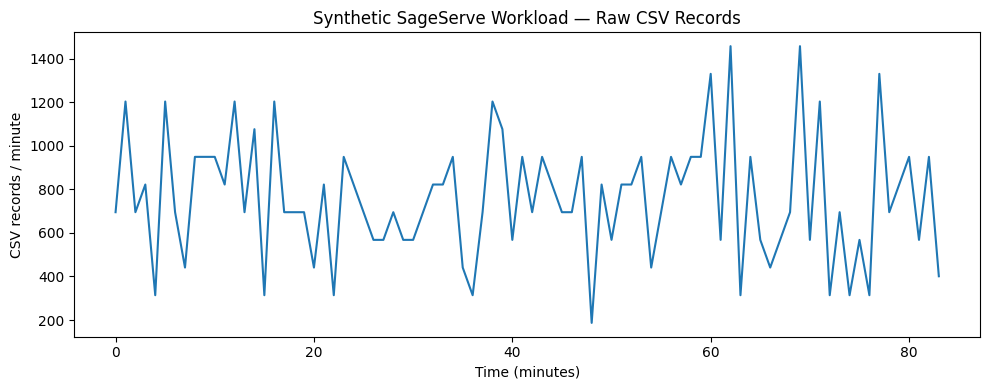

In [7]:
import matplotlib.pyplot as plt

records_per_minute = (
    df.groupby(df["arrival_timestamp"] // 60)
      .size()
)

plt.figure(figsize=(10, 4))
plt.plot(records_per_minute.index, records_per_minute.values)
plt.xlabel("Time (minutes)")
plt.ylabel("CSV records / minute")
plt.title("Synthetic SageServe Workload — Raw CSV Records")
plt.tight_layout()
plt.show()


## 6. Interpretation of the plot

The generated trace shows substantial variation in the number of raw CSV records across time.

However, the spikes need to be interpreted carefully because some timestamps contain up to 128 rows while the trace has only one unique request ID per timestamp.

A high row count can therefore come from batch expansion rather than many independent arrivals.

### Current conclusion

The trace has temporal variation, but **the correct workload signal for ARIMA forecasting has not yet been established**.

Before creating forecast files, we should inspect:

- how SageServe interprets `batch_size`;
- how requests are expanded/processed;
- how the ARIMA arbiter consumes forecast data;
- how the existing SageServe trace/forecast notebooks construct the forecast signal.



## 7. Current trace summary

| Property | Value |
|---|---:|
| CSV rows | 63,674 |
| Unique request IDs | 5,000 |
| Unique arrival timestamps | 5,000 |
| Arrival time range | 0–4999 s |
| Approx. duration | 83.3 min |
| Models | A, B, C, D |
| Region codes | 102, 201, 210, 120, 21, 12 |
| Maximum rows at one timestamp | 128 |

### Main takeaway

`random_trace.csv` is suitable for **local simulator validation**, but the raw number of CSV rows is not by itself a valid request-arrival metric.

The next step is to identify the exact workload signal SageServe uses for scaling/forecasting before running the forecast-aware comparison.
